# Cross-Dataset Clustering Experiment Consolidation — Final

Run this notebook only after both final dataset notebooks have completed and saved their outputs. It enforces the final artifact contract and requires stability, balance, separation, meaningful external effects, and reliable incremental predictive value before recommending predictive use.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports and output locations

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
ASSIST_DIR = Path('/content/drive/MyDrive/datasets/assistments_final_outputs')
KDD_DIR = Path('/content/drive/MyDrive/datasets/kdd_final_outputs')
OUTPUT_DIR = Path('/content/drive/MyDrive/datasets/clustering_final_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIRS = {'ASSISTments': ASSIST_DIR, 'KDD': KDD_DIR}

STABILITY_ARI_THRESHOLD = 0.80
MIN_CLUSTER_FRACTION_THRESHOLD = 0.03
SILHOUETTE_CAUTION_THRESHOLD = 0.10
MEANINGFUL_EFFECT_THRESHOLD = 0.01

## Validate the saved-output contract

In [3]:
required_files = [
    'run_config.json', 'learner_cluster_assignments.csv',
    'k_selection_results.csv', 'algorithm_comparison_repeats.csv',
    'algorithm_comparison_summary.csv', 'feature_ablation_results.csv',
    'selected_cluster_profiles.csv', 'temporal_validation_tests.csv',
    'future_success_prediction_baselines.csv',
    'incremental_cluster_test.csv',
]
missing = {}
for dataset, directory in EXPERIMENT_DIRS.items():
    missing[dataset] = [name for name in required_files if not (directory / name).exists()]
    print(dataset, 'directory:', directory)
    print('Missing:', missing[dataset] or 'none')
if any(missing.values()):
    raise FileNotFoundError('Run the revised dataset notebooks first. Missing files are listed above.')

ASSISTments directory: /content/drive/MyDrive/datasets/assistments_final_outputs
Missing: none
KDD directory: /content/drive/MyDrive/datasets/kdd_final_outputs
Missing: none


## Load and standardise both experiments

In [4]:
def read_json(path):
    with open(path) as file:
        return json.load(file)

def read_indexed_csv(path, expected_index):
    table = pd.read_csv(path)
    unnamed = [col for col in table.columns if col.startswith('Unnamed:')]
    if expected_index not in table.columns and unnamed:
        table = table.rename(columns={unnamed[0]: expected_index})
    return table

experiments = {}
for dataset, directory in EXPERIMENT_DIRS.items():
    experiments[dataset] = {
        'config': read_json(directory / 'run_config.json'),
        'assignments': pd.read_csv(directory / 'learner_cluster_assignments.csv'),
        'k': read_indexed_csv(directory / 'k_selection_results.csv', 'K'),
        'algorithm_repeats': pd.read_csv(directory / 'algorithm_comparison_repeats.csv'),
        'algorithm_summary': read_indexed_csv(directory / 'algorithm_comparison_summary.csv', 'Model'),
        'ablation': read_indexed_csv(directory / 'feature_ablation_results.csv', 'FeatureSet'),
        'profiles': read_indexed_csv(directory / 'selected_cluster_profiles.csv', 'cluster'),
        'temporal': pd.read_csv(directory / 'temporal_validation_tests.csv'),
        'prediction': pd.read_csv(directory / 'future_success_prediction_baselines.csv'),
        'incremental': pd.read_csv(directory / 'incremental_cluster_test.csv'),
        'ablation_agreement': pd.read_csv(directory / 'feature_ablation_agreement.csv') if (directory / 'feature_ablation_agreement.csv').exists() else None,
    }
    print(dataset, 'selected K:', experiments[dataset]['config']['selected_k'])

ASSISTments selected K: 2
KDD selected K: 3


## Dataset and representation overview

In [5]:
known_raw_rows = {'ASSISTments': 6_123_270, 'KDD': 809_694}
overview_rows = []
for dataset, exp in experiments.items():
    assignments = exp['assignments']
    config = exp['config']
    selected_k = int(config['selected_k'])
    k_row = exp['k'].loc[exp['k']['K'].astype(int) == selected_k].iloc[0]
    overview_rows.append({
        'Dataset': dataset, 'RawRows': known_raw_rows[dataset],
        'EligibleLearners': len(assignments), 'MainFeatureSet': config['main_feature_set'],
        'SelectedK': selected_k,
        'SelectionStatus': config.get('selected_solution_status', 'not_recorded'),
        'Silhouette': k_row['Silhouette'],
        'DBI': k_row['DBI'], 'CHI': k_row['CHI'],
        'StabilityARI': k_row['StabilityARI'], 'StabilityNMI': k_row['StabilityNMI'],
        'MinClusterFraction': k_row['MinClusterFraction'],
    })
dataset_overview = pd.DataFrame(overview_rows)
display(dataset_overview)

,Dataset,RawRows,EligibleLearners,MainFeatureSet,SelectedK,SelectionStatus,Silhouette,DBI,CHI,StabilityARI,StabilityNMI,MinClusterFraction
0,ASSISTments,6123270,33335,behaviour_mastery_no_affect,2,accepted,0.144771,4.715064,597.705099,0.957682,0.909020,0.250037
1,KDD,809694,565,behaviour_mastery,3,exploratory_fallback,0.109580,2.550429,29.515207,0.643451,0.614865,0.017699


## Consolidated K selection, algorithms, ablations and temporal tests

In [6]:
def combine_table(key):
    frames = []
    for dataset, exp in experiments.items():
        frame = exp[key].copy()
        frame.insert(0, 'Dataset', dataset)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True, sort=False)

combined_k = combine_table('k')
combined_algorithm_repeats = combine_table('algorithm_repeats')
combined_algorithm_summary = combine_table('algorithm_summary')
combined_ablation = combine_table('ablation')
combined_temporal = combine_table('temporal')
combined_prediction = combine_table('prediction')
display(combined_k)
display(combined_algorithm_summary)
display(combined_ablation)
display(combined_temporal)
display(combined_prediction)

,Dataset,K,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction,StabilityARI,StabilityNMI,Inertia
0,ASSISTments,2,0.144771,4.715064,597.705099,2,0.0,0.250037,0.957682,0.909020,4.419677e+06
1,ASSISTments,3,0.091704,4.845139,503.505403,3,0.0,0.203390,0.694780,0.717002,4.354301e+06
2,ASSISTments,4,0.076534,4.510851,436.916256,4,0.0,0.017062,0.751565,0.732823,4.307018e+06
3,ASSISTments,5,0.030400,4.387292,406.492794,5,0.0,0.014887,0.684827,0.683042,4.259017e+06
4,ASSISTments,6,0.033389,3.975277,381.876904,6,0.0,0.001012,0.859164,0.789680,4.216761e+06
5,ASSISTments,7,0.029417,3.751694,334.431853,7,0.0,0.000262,0.668685,0.678547,4.202453e+06
6,ASSISTments,8,0.023538,3.780948,325.141278,8,0.0,0.000900,0.666128,0.674493,4.163316e+06
7,ASSISTments,9,-0.017877,3.837405,313.316227,9,0.0,0.000862,0.656268,0.675900,4.130395e+06
8,KDD,2,0.100668,2.942789,39.580469,2,0.0,0.402655,0.512261,0.501534,4.223247e+04
9,KDD,3,0.109580,2.550429,29.515207,3,0.0,0.017699,0.643451,0.614865,4.060829e+04


,Dataset,Model,SilhouetteMean,SilhouetteStd,DBIMean,CHIMean,MinClusterFractionMean,MinClusterFractionMinimum
0,ASSISTments,KMeans,0.158872,0.008615,4.664507,113.886473,0.237600,0.23020
1,ASSISTments,Hierarchical,0.122581,0.022145,5.960084,71.622991,0.257040,0.23340
2,ASSISTments,GMM-diagonal,0.076874,0.004031,7.143906,43.165228,0.410600,0.40340
3,KDD,Hierarchical,0.105553,0.062649,2.835374,21.247213,0.055679,0.00831
4,KDD,KMeans,0.101368,0.047059,2.725992,24.414788,0.053463,0.00831
5,KDD,GMM-diagonal,0.085228,0.108371,6.370890,6.297469,0.090582,0.00277


,Dataset,FeatureSet,InputFeatures,OutputDimensions,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
0,ASSISTments,behaviour_mastery,182,159,0.131974,4.761520,610.701290,2,0.0,0.258100
1,ASSISTments,behaviour_mastery_no_affect,178,156,0.144771,4.715064,597.705099,2,0.0,0.250037
2,ASSISTments,combined_with_exposure,187,161,0.233084,5.052204,611.600182,2,0.0,0.219252
3,ASSISTments,exposure_only,5,3,0.515681,0.797199,21816.708547,2,0.0,0.217302
4,KDD,behaviour_mastery,111,69,0.109580,2.550429,29.515207,3,0.0,0.017699
5,KDD,combined_with_exposure,116,71,0.067922,3.156906,28.795115,3,0.0,0.099558
6,KDD,exposure_only,5,2,0.429820,0.855867,535.266014,3,0.0,0.283186


,Dataset,Outcome,KruskalH,PValue,EpsilonSquared,HolmAdjustedPValue
0,ASSISTments,future_success_rate,5681.827670,0.000000e+00,0.170427,0.000000e+00
1,ASSISTments,future_avg_hints,8089.427276,0.000000e+00,0.242655,0.000000e+00
2,ASSISTments,future_avg_attempts,3449.055263,0.000000e+00,0.103443,0.000000e+00
3,ASSISTments,future_bottom_hint_rate,7858.291535,0.000000e+00,0.236160,0.000000e+00
4,ASSISTments,learning_gain,455.697886,4.150640e-101,0.013641,8.301280e-101
5,ASSISTments,future_active_span_days,4.758570,2.915275e-02,0.000113,2.915275e-02
6,KDD,future_success_rate,154.023282,3.583185e-34,0.270504,2.149911e-33
7,KDD,future_avg_hints,129.241419,8.621492e-29,0.226408,4.310746e-28
8,KDD,future_avg_incorrects,91.258913,1.525383e-20,0.158824,6.101530e-20
9,KDD,future_avg_duration_log,21.434782,2.215625e-05,0.034581,6.646874e-05


,Dataset,Model,MAE
0,ASSISTments,Behaviour model + cluster,0.117404
1,ASSISTments,Behaviour model,0.117702
2,ASSISTments,Calibrated early success,0.123478
3,ASSISTments,Early success carried forward,0.124499
4,ASSISTments,Cluster only,0.151932
5,ASSISTments,Global mean,0.169462
6,KDD,Calibrated early success,0.056180
7,KDD,Early success carried forward,0.058719
8,KDD,Cluster only,0.064333
9,KDD,Behaviour model + cluster,0.064418


## Is clustering exposure-driven?

Eta-squared is calculated directly from learner assignments. This compares how strongly cluster membership is associated with exposure variables and with behavioural/performance variables.

In [7]:
exposure_features = {
    'log_interactions', 'log_active_days', 'interactions_per_active_day',
    'observed_supported_skills', 'mean_mastery_confidence',
}
identifier_features = {
    'user_id', 'learner_id', 'student_id', 'anon student id', 'row',
}

def eta_squared(values, labels):
    frame = pd.DataFrame({'value': pd.to_numeric(values, errors='coerce'), 'cluster': labels}).dropna()
    if frame.empty or frame['value'].nunique() < 2:
        return np.nan
    grand = frame['value'].mean()
    between = sum(len(group) * (group['value'].mean() - grand) ** 2 for _, group in frame.groupby('cluster'))
    total = ((frame['value'] - grand) ** 2).sum()
    return between / total if total > 0 else np.nan

driver_rows = []
for dataset, exp in experiments.items():
    assignments = exp['assignments'].copy()
    for feature in assignments.select_dtypes(include='number').columns:
        normalised_feature = feature.strip().lower()
        if (
            normalised_feature == 'cluster'
            or feature.startswith('Unnamed:')
            or normalised_feature in identifier_features
            or normalised_feature.endswith('_id')
        ):
            continue
        category = 'Exposure' if feature in exposure_features else 'Behaviour/performance'
        driver_rows.append({
            'Dataset': dataset, 'Feature': feature, 'Category': category,
            'EtaSquared': eta_squared(assignments[feature], assignments['cluster']),
        })
cluster_drivers = pd.DataFrame(driver_rows).sort_values(['Dataset', 'EtaSquared'], ascending=[True, False])
assert not cluster_drivers['Feature'].str.lower().isin(identifier_features).any()
driver_summary = cluster_drivers.groupby(['Dataset', 'Category'])['EtaSquared'].agg(['max', 'mean', 'median']).reset_index()
display(cluster_drivers.groupby('Dataset').head(15))
display(driver_summary)

,Dataset,Feature,Category,EtaSquared
7,ASSISTments,avg_hints,Behaviour/performance,0.485345
9,ASSISTments,bottom_hint_rate,Behaviour/performance,0.461474
15,ASSISTments,first_action_0_rate,Behaviour/performance,0.392164
16,ASSISTments,first_action_1_rate,Behaviour/performance,0.387780
5,ASSISTments,success_rate,Behaviour/performance,0.383747
8,ASSISTments,avg_attempts,Behaviour/performance,0.192342
14,ASSISTments,avg_bored,Behaviour/performance,0.068648
13,ASSISTments,avg_concentrating,Behaviour/performance,0.053703
17,ASSISTments,first_action_2_rate,Behaviour/performance,0.009226
11,ASSISTments,avg_frustrated,Behaviour/performance,0.007370


,Dataset,Category,max,mean,median
0,ASSISTments,Behaviour/performance,0.485345,0.188246,0.068648
1,ASSISTments,Exposure,0.003293,0.001336,0.000180
2,KDD,Behaviour/performance,0.466915,0.146390,0.082138
3,KDD,Exposure,0.074196,0.049771,0.059227


## Three decision questions

In [8]:
decision_rows = []
for dataset, exp in experiments.items():
    overview = dataset_overview.set_index('Dataset').loc[dataset]
    temporal = exp['temporal']
    future_success = temporal.loc[temporal['Outcome'] == 'future_success_rate']
    future_effect = future_success['EpsilonSquared'].iloc[0] if not future_success.empty and 'EpsilonSquared' in future_success else np.nan
    future_adjusted_p = future_success['HolmAdjustedPValue'].iloc[0] if not future_success.empty and 'HolmAdjustedPValue' in future_success else np.nan

    drivers = cluster_drivers[cluster_drivers['Dataset'] == dataset]
    max_exposure = drivers.loc[drivers['Category'] == 'Exposure', 'EtaSquared'].max()
    max_behaviour = drivers.loc[drivers['Category'] == 'Behaviour/performance', 'EtaSquared'].max()

    prediction = exp['prediction'].set_index('Model')['MAE']
    incremental_mae = prediction.get('Behaviour model', np.nan) - prediction.get('Behaviour model + cluster', np.nan)
    reliability_value = exp['incremental']['ReliablePositiveImprovement'].iloc[0]
    if isinstance(reliability_value, str):
        incremental_reliable = reliability_value.strip().lower() in {'true', '1', 'yes'}
    else:
        incremental_reliable = bool(reliability_value) if pd.notna(reliability_value) else False
    ci_lower = pd.to_numeric(exp['incremental']['CI95Lower'].iloc[0], errors='coerce')
    ci_upper = pd.to_numeric(exp['incremental']['CI95Upper'].iloc[0], errors='coerce')
    incremental_reliable = bool(incremental_reliable and pd.notna(ci_lower) and ci_lower > 0)

    stable = overview['StabilityARI'] >= STABILITY_ARI_THRESHOLD
    balanced = overview['MinClusterFraction'] >= MIN_CLUSTER_FRACTION_THRESHOLD
    separated = overview['Silhouette'] >= SILHOUETTE_CAUTION_THRESHOLD
    selection_accepted = bool(exp['config'].get('selection_passed_gates', True))
    structurally_valid = bool(selection_accepted and stable and balanced and separated)
    effect_supported = bool(
        pd.notna(future_effect) and future_effect >= MEANINGFUL_EFFECT_THRESHOLD
        and pd.notna(future_adjusted_p) and future_adjusted_p < 0.05
    )
    meaningful = bool(max_behaviour > max_exposure and effect_supported)
    predictive_valid = bool(structurally_valid and meaningful and incremental_reliable)
    decision_rows.append({
        'Dataset': dataset,
        'SelectionStatus': exp['config'].get('selected_solution_status', 'accepted' if selection_accepted else 'exploratory_fallback'),
        'Q1_Stable': bool(stable),
        'Q1_Balanced': bool(balanced),
        'Q1_SeparationAtLeastCautious': bool(separated),
        'Q1_StructurallyValid': structurally_valid,
        'Q2_BehaviourDominatesExposure': max_behaviour > max_exposure,
        'Q2_FutureSuccessEffect': future_effect,
        'Q2_FutureSuccessAdjustedP': future_adjusted_p,
        'Q2_Meaningful': meaningful,
        'Q3_IncrementalMAEImprovement': incremental_mae,
        'Q3_CI95Lower': ci_lower, 'Q3_CI95Upper': ci_upper,
        'Q3_ReliableIncrementalValue': incremental_reliable,
        'RecommendedUse': (
            'Predictive and descriptive' if predictive_valid
            else 'Descriptive only' if structurally_valid and meaningful
            else 'Do not operationalise'
        ),
    })
decision_table = pd.DataFrame(decision_rows)
display(decision_table)

,Dataset,SelectionStatus,Q1_Stable,Q1_Balanced,Q1_SeparationAtLeastCautious,Q1_StructurallyValid,Q2_BehaviourDominatesExposure,Q2_FutureSuccessEffect,Q2_FutureSuccessAdjustedP,Q2_Meaningful,Q3_IncrementalMAEImprovement,Q3_CI95Lower,Q3_CI95Upper,Q3_ReliableIncrementalValue,RecommendedUse
0,ASSISTments,accepted,True,True,True,True,True,0.170427,0.000000e+00,True,0.000297,0.000010,0.000568,True,Predictive and descriptive
1,KDD,exploratory_fallback,False,False,True,False,True,0.270504,2.149911e-33,True,0.000079,-0.001566,0.001737,False,Do not operationalise


## Report-ready figures

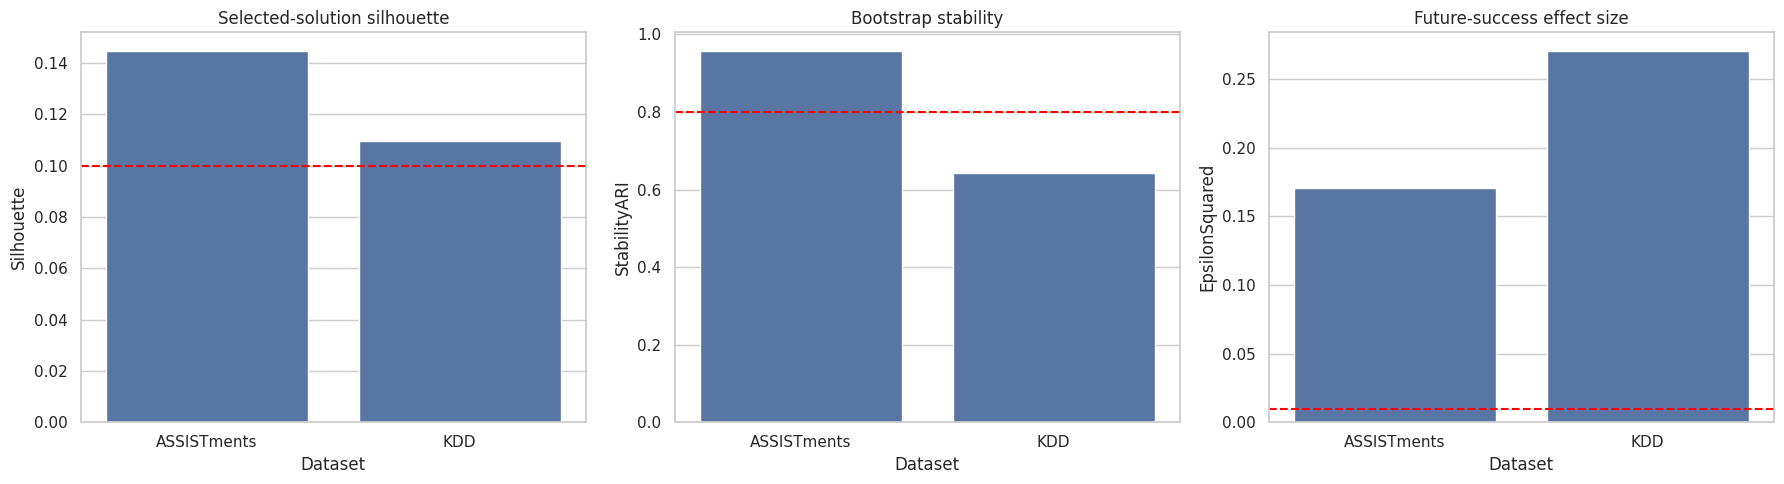

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=dataset_overview, x='Dataset', y='Silhouette', ax=axes[0])
axes[0].axhline(SILHOUETTE_CAUTION_THRESHOLD, color='red', linestyle='--')
axes[0].set_title('Selected-solution silhouette')
sns.barplot(data=dataset_overview, x='Dataset', y='StabilityARI', ax=axes[1])
axes[1].axhline(STABILITY_ARI_THRESHOLD, color='red', linestyle='--')
axes[1].set_title('Bootstrap stability')
future_plot = combined_temporal[combined_temporal['Outcome'] == 'future_success_rate']
sns.barplot(data=future_plot, x='Dataset', y='EpsilonSquared', ax=axes[2])
axes[2].axhline(MEANINGFUL_EFFECT_THRESHOLD, color='red', linestyle='--')
axes[2].set_title('Future-success effect size')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_dataset_key_evidence.png', dpi=200, bbox_inches='tight')
plt.show()

## Save consolidated tables and an evidence-based findings file

In [10]:
tables = {
    'dataset_overview.csv': dataset_overview,
    'k_selection_all.csv': combined_k,
    'algorithm_repeats_all.csv': combined_algorithm_repeats,
    'algorithm_summary_all.csv': combined_algorithm_summary,
    'feature_ablation_all.csv': combined_ablation,
    'temporal_validation_all.csv': combined_temporal,
    'prediction_baselines_all.csv': combined_prediction,
    'cluster_driver_effects.csv': cluster_drivers,
    'cluster_driver_summary.csv': driver_summary,
    'clustering_decision_table.csv': decision_table,
}
for filename, table in tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)

lines = [
    '# Consolidated Clustering Findings', '',
    'Thresholds are decision aids rather than universal definitions of educational validity.', '',
]
for _, row in decision_table.iterrows():
    lines.extend([
        f"## {row['Dataset']}", '',
        f"- Selection status: {row['SelectionStatus']}",
        f"- Stable: {row['Q1_Stable']}",
        f"- Sufficiently balanced: {row['Q1_Balanced']}",
        f"- Separation reaches the cautious threshold: {row['Q1_SeparationAtLeastCautious']}",
        f"- Passes all structural gates: {row['Q1_StructurallyValid']}",
        f"- Behavioural differences dominate exposure: {row['Q2_BehaviourDominatesExposure']}",
        f"- Future-success epsilon-squared: {row['Q2_FutureSuccessEffect']:.4f}",
        f"- Future-success Holm-adjusted p-value: {row['Q2_FutureSuccessAdjustedP']:.6g}",
        f"- Incremental cluster MAE improvement: {row['Q3_IncrementalMAEImprovement']:.6f}",
        f"- Incremental-value 95% CI: [{row['Q3_CI95Lower']:.6f}, {row['Q3_CI95Upper']:.6f}]",
        f"- Reliable incremental predictive value: {row['Q3_ReliableIncrementalValue']}",
        f"- Recommended use: {row['RecommendedUse']}", '',
    ])
with open(OUTPUT_DIR / 'consolidated_findings.md', 'w', encoding='utf-8') as file:
    file.write('\n'.join(lines))

for filename, table in tables.items():
    assert len(pd.read_csv(OUTPUT_DIR / filename)) == len(table)
print('Saved and verified consolidated outputs:', OUTPUT_DIR)
print('\n'.join(f'{path.name}: {path.stat().st_size:,} bytes' for path in sorted(OUTPUT_DIR.iterdir()) if path.is_file()))

Saved and verified consolidated outputs: /content/drive/MyDrive/datasets/clustering_final_outputs
algorithm_repeats_all.csv: 4,390 bytes
algorithm_summary_all.csv: 845 bytes
cluster_driver_effects.csv: 2,320 bytes
cluster_driver_summary.csv: 370 bytes
clustering_decision_table.csv: 643 bytes
consolidated_findings.md: 1,136 bytes
cross_dataset_key_evidence.png: 100,992 bytes
dataset_overview.csv: 481 bytes
feature_ablation_all.csv: 914 bytes
k_selection_all.csv: 2,453 bytes
prediction_baselines_all.csv: 582 bytes
temporal_validation_all.csv: 1,220 bytes
